In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow version: 2.21.0
GPU disponible: 0


Descarga del dataset, normalización de imágenes, aplanamiento y muestra del tamaño de train y test.

In [2]:
# Descargar MNIST
(X_train_full, y_train_full), (X_test_full, y_test_full) = keras.datasets.mnist.load_data()

# normalizar imágenes
X_train = X_train_full.astype('float32') / 255.0
X_test  = X_test_full.astype('float32') / 255.0

# aplanar todas las imágenes
X_train_flat = X_train.reshape(-1, 28*28)
X_test_flat  = X_test.reshape(-1, 28*28)
y_train_bin  = y_train_full
y_test_bin   = y_test_full

print(f"Train: {X_train_flat.shape}")
print(f"Test:  {X_test_flat.shape}")

Train: (60000, 784)
Test:  (10000, 784)


Definición del modelo con la diferenciación del número de neuronas en la capa final

In [5]:
model = keras.Sequential([
    # capa oculta 1: 64 neuronas, relu descarta valores negativos
    keras.layers.Dense(64, activation='relu', input_shape=(784,)),
    # capa oculta 2: 32 neuronas, sigue aprendiendo patrones
    keras.layers.Dense(32, activation='relu'),
    # capa de salida: 10 neuronas (una por dígito), softmax da probabilidades que suman 1
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

Compilación del modelo

In [6]:
model.compile(
    # adam ajusta los pesos automáticamente durante el entrenamiento
    optimizer='adam',
    # sparse_categorical_crossentropy mide el error en problemas de múltiples clases
    loss='sparse_categorical_crossentropy',
    # accuracy para ver el porcentaje de aciertos
    metrics=['accuracy']
)

Entrenamiento del modelo

In [7]:
history = model.fit(
    # imágenes aplanadas y etiquetas 0-9
    X_train_flat, y_train_bin,
    # pasa por todos los datos 10 veces
    epochs=10,
    # procesa 32 imágenes a la vez
    batch_size=32,
    # reserva el 20% de los datos para validación
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9053 - loss: 0.3301 - val_accuracy: 0.9494 - val_loss: 0.1761
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9565 - loss: 0.1449 - val_accuracy: 0.9627 - val_loss: 0.1275
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9683 - loss: 0.1048 - val_accuracy: 0.9687 - val_loss: 0.1066
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9750 - loss: 0.0822 - val_accuracy: 0.9705 - val_loss: 0.1067
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9795 - loss: 0.0665 - val_accuracy: 0.9659 - val_loss: 0.1194
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9825 - loss: 0.0562 - val_accuracy: 0.9724 - val_loss: 0.0990
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9852 - loss: 0.0478 - val_accuracy: 0.9724 - val_loss: 0.1012
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9872 - loss: 0.0405 - 

Evaluación del modelo con datos de test (datos que no ha visto)

In [8]:
loss, accuracy = model.evaluate(X_test_flat, y_test_bin)

# mostramos los resultados
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step - accuracy: 0.9740 - loss: 0.1036
Loss: 0.1036
Accuracy: 97.40%


Visualización de la evolución del entrenamiento

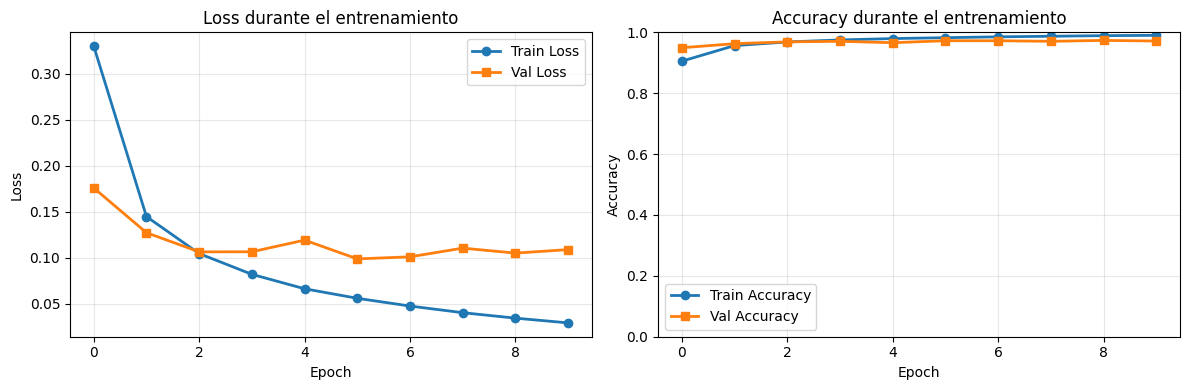

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# gráfico de loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2, marker='o')
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2, marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss durante el entrenamiento')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# gráfico de accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, marker='o')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy durante el entrenamiento')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

Muy buenas gráficas. El modelo ha aprendido bien.

* Loss: la de train baja consistentemente. La de validación se estabiliza en torno a 0.10, lo cual es normal.
* Accuracy: ambas cerca del 97-98% desde el principio. El modelo distingue los 10 dígitos casi perfectamente.

El único detalle a observar es que a partir del epoch 4 la val loss deja de bajar mientras la train sigue bajando — señal leve de overfitting, pero sin consecuencias graves dado que la accuracy de validación se mantiene estable.

Realizamos predicciones sobre las primeras 5 imágenes del test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


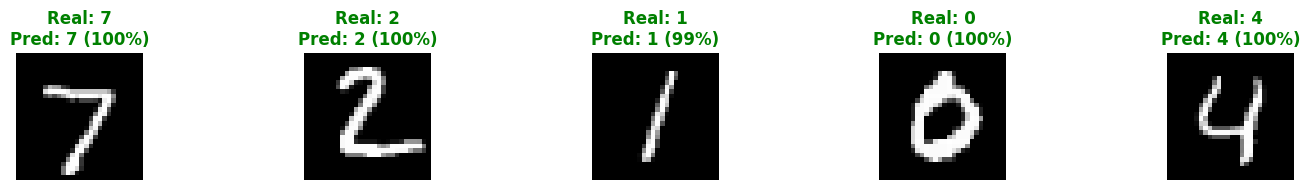

In [10]:
predictions = model.predict(X_test_flat[:5])

# mostramos las imágenes con su predicción
fig, axes = plt.subplots(1, 5, figsize=(15, 2))

for i in range(5):
    axes[i].imshow(X_test_flat[i].reshape(28, 28), cmap='gray')

    # neurona con mayor probabilidad es la clase predicha
    pred_class = np.argmax(predictions[i])
    # probabilidad de la clase ganadora
    pred_prob = predictions[i][pred_class]
    real_class = y_test_bin[i]

    # verde si acierta, rojo si falla
    color = 'green' if pred_class == real_class else 'red'

    title = f"Real: {real_class}\nPred: {pred_class} ({pred_prob:.0%})"
    axes[i].set_title(title, color=color, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()